In [1]:
from astropy import units as u
from astropy.constants import k_B, R, G, c
import spacehub_calc
from spacehub_calc import ensure_unit
import numpy as np
import subprocess
from matplotlib import pyplot as plt
from matplotlib import animation
from IPython.display import display, clear_output, HTML
import seaborn as sns
import pandas as pd
from scipy.interpolate import PchipInterpolator

In [2]:
def interp_intercept(x, y, intercept=0, npoints=1e3, returnCurves=False):
    f = PchipInterpolator(x, y)
    x_fine = np.linspace(min(x), max(x), int(npoints))
    y_fine = f(x_fine)
    offset = y_fine - intercept
    idx_list = np.argwhere(np.diff(np.sign(offset))).flatten()
    if len(idx_list) == 0:
        print(f"No crossing found")
        return [0,0]
    
    idx = idx_list[0]
    point = [x_fine[idx], y_fine[idx]]
    if returnCurves:
        return point, x_fine, y_fine
    else:
        return point

In [3]:
#temp
T=7.75*u.hr
M=1.4*u.Msun
a=((T**2*G*M)/(np.pi**2))**(1/3)
a.to(u.AU)

<Quantity 0.01635777 AU>

#### Theoretical predictions



In [4]:
rho = (1e-9*u.g/(u.cm**(3))).si
print(rho.to(u.kg/u.cm**(3)))
T = 200*u.K
gamma = 5/3 #Monotomic gas
molarMass = 2.016 * u.g/u.mol
c_ideal = np.sqrt(gamma * R * T / molarMass)
c_ideal.to(u.km/u.s)


1.0000000000000002e-12 kg / cm3


<Quantity 1.17249555 km / s>

In [5]:
M = 10 * u.Msun
Rs1 = 2*G*M/(c**2)
rho = (1e-9*u.g/(u.cm**(3))).si
deltaT = 1*u.yr
vrel = [1,0,0]*u.km/u.s
vmag = 1*u.km/u.s
Mach = vmag / c_ideal
I  = 0.5 * np.log((1+Mach)/(1-Mach))-Mach
# Delta p = F_dyn * Delta t
Fdyn = (I * vrel *(4 * np.pi * (G**2) * (M**2) * rho / (vmag**3))).si
dP = Fdyn*deltaT
(dP/M).to(u.km/u.s)

<Quantity [14533.4129385,     0.       ,     0.       ] km / s>

In [6]:
compilecmd = "g++ -std=c++17 -O3 -pthread simulations/dragforces/spTest.cpp -o simulations/dragforces/spTest"

if False:
    res = subprocess.run(compilecmd, capture_output=True, shell=True)
    print(res.stderr)
    res = subprocess.run("simulations/dragforces/spTest", capture_output=True, shell=True)
    print(res.stderr)
    print(res.stdout)

#### Test $F_{aero}$ (Success)

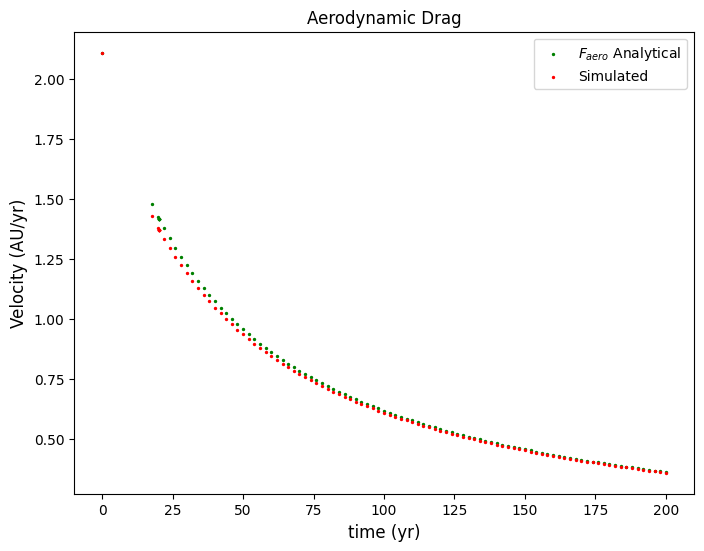

In [7]:
dfi = pd.read_csv("F_aero_successful_test.csv")
df_aero = dfi[dfi["id"]==0]

fig, ax = plt.subplots(figsize=(8,6)) 


uyr = u.yr/(2*np.pi)
t_real = df_aero["time"] / (2*np.pi)
vdata_real = df_aero["vx"] * (2*np.pi)
v0 = 10 * u.km/u.s
rho =  1e-9 * u.kg/(u.cm*u.cm*u.cm)
R = 10 * u.Rsun
M = 1 * u.Msun
#ax.scatter(t, 1/(A*t+1/v0))
def v_aero(t):
    t = t * u.yr
    K = np.pi * R**2 * rho * v0 / M
    
    return v0 / (1 + K*t)

vt = [v_aero(t).to(u.AU/(u.yr)).value for t in t_real]

ax.scatter(t_real, vt, color="green", s=2, label=r"$F_{aero}$ Analytical")
ax.scatter(t_real, vdata_real, color="red", s=2, label="Simulated")
ax.set_xlabel("time (yr)", fontsize=12)
ax.set_ylabel(r"Velocity (AU/yr)", fontsize=12)
ax.set_title("Aerodynamic Drag")
ax.legend(fontsize=10)

#### Test $F_{dyn}$ (Success)

(0.0, 3.0)

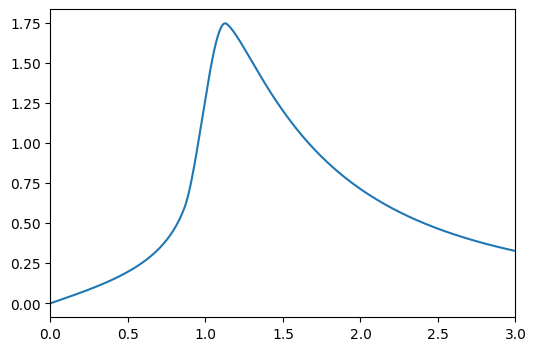

In [8]:
fig, ax = plt.subplots(figsize=(6,4)) 
# Lambda functions for dimensionless calculations
I_sup = lambda M, logR: (0.5 * np.log(1 - 1 / M**2) + logR) / M**2

I_sub = lambda M: (0.5 * np.log((1 + M) / (1 - M)) - M) / M**2

dIdM_sup = lambda M, logR: (-2 * logR + 1 / (M**2 - 1) - np.log(1 - 1 / M**2)) / M**3

dIdM_sub = lambda M: (M**3 + (1 - M**2) * np.log((1 + M) / (1 - M)) - 2 * M) / (M**3 * (M**2 - 1))


logR = 3.0 * u.dimensionless_unscaled; #Chaning this to one gives the expected asymptotic behavior
eps = (1 / np.exp(2.0 * logR.value / 3.0)) * u.dimensionless_unscaled

x1 = (1 - eps.value) * u.dimensionless_unscaled
x2 = (1 + eps.value) * u.dimensionless_unscaled

y1 = I_sub(x1.value) * u.dimensionless_unscaled
y2 = I_sup(x2.value, logR.value) * u.dimensionless_unscaled

k1 = dIdM_sub(x1.value) * u.dimensionless_unscaled
k2 = dIdM_sup(x2.value, logR.value) * u.dimensionless_unscaled

a = (k1 * (x2 - x1) - (y2 - y1))
b = (-k2 * (x2 - x1) + (y2 - y1))

# Helper functions
tt = lambda M: (M - x1) / (x2 - x1)

def connect(M):
    t = tt(M)
    return (1 - t) * y1 + y2 * t + (1 - t) * t * (t * b + (1 - t) * a)

def I(Mach):

    eps = 1 / np.exp(2.0 * logR / 3.0);
    if Mach >= (1 + eps) * u.dimensionless_unscaled:
        I = (0.5 * np.log(1 - 1 / (Mach**2)) + logR) / (Mach**2)
        
    elif (0.1 * u.dimensionless_unscaled < Mach) and (Mach < (1 - eps) * u.dimensionless_unscaled):
        I = (0.5 * np.log((1 + Mach) / (1 - Mach)) - Mach) / (Mach**2)
        
    elif Mach <= 0.1 * u.dimensionless_unscaled:
        I = Mach / 3.0 
        
    else:
        I = connect(Mach)
        return I
    return I

machs = np.linspace(0, 100, 10000)
Is = [I(M) for M in machs]
ax.plot(machs, Is)
ax.set_xlim(0,3)


In [9]:


uyr = u.yr/(2*np.pi)

v0 = 100 * u.km/u.s
rho =  1e-12 * u.kg/(u.cm*u.cm*u.cm)
R = 12*u.km
M = 0.4 * u.Msun
cs = 10 * u.km/u.s;

time = [0*u.yr]
velocity = [v0]
machs = [(v0/cs).si.value]
while velocity[-1].value > 1e-6:
    v = velocity[-1]
    t = time[-1]
    mach = (v/cs).si.value
    machs.append(mach)
    dt = 0.01*u.yr
    Fm = ( I(mach*u.dimensionless_unscaled) * (rho*4*np.pi*(G*M)**2) ) / cs**2 /M
    dv = dt*Fm
    time.append(t+dt)
    velocity.append(v-dv)
    #print(v-dv)
    

#Idebug = [(   1*u.yr *( I(machi*u.dimensionless_unscaled) * (rho*4*np.pi*(G*M)**2) ) / cs**2 /M  ).to(u.km/u.s).value for machi in np.linspace(10,0,1000)]


Text(0.5, 1.0, 'Dynamical Friction')

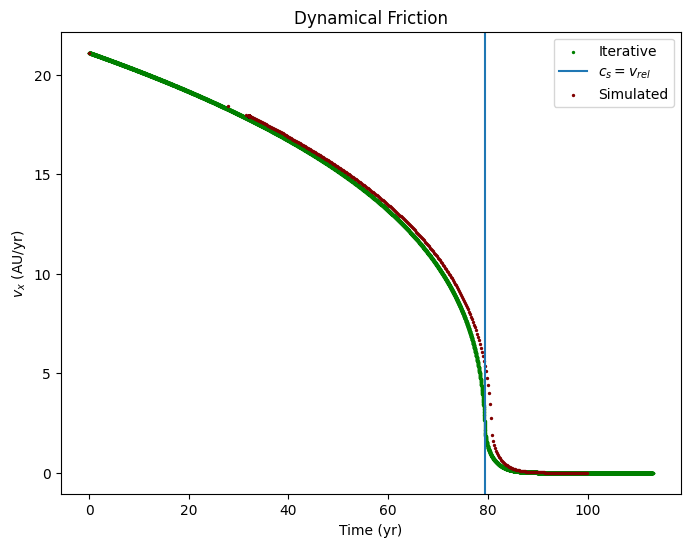

In [10]:
fig, ax = plt.subplots(figsize=(8,6))
# Plot analytical solution
ax.scatter([t.value for t in time], [v.to(u.AU/u.yr).value for v in velocity], s=2, label="Iterative", color="green")
idx_cross = np.where(np.diff(np.sign(np.array(machs) - 1)) != 0)[0]

ax.axvline(x=time[idx_cross[0]].value, label=r"$c_s=v_{rel}$")
# Plot simulated solution
dfi = pd.read_csv("testdynfriction.csv")
df_dyn = dfi[dfi["id"]==0]
t_real = df_dyn["time"] / (2*np.pi)
vdata_real = df_dyn["vx"] * (2*np.pi)
ax.scatter(t_real, vdata_real, color="maroon", s=2, label="Simulated")
ax.legend()
ax.set_xlabel("Time (yr)")
ax.set_ylabel(r"$v_x$ (AU/yr)")
ax.set_title("Dynamical Friction")

#### Test $F_{BH}$ 

In [11]:
uyr = u.yr/(2*np.pi)

v0 = 100 * u.km/u.s
rho =  1e-12 * u.kg/(u.cm*u.cm*u.cm)
R = 12*u.km
M = 0.4 * u.Msun
cs = 10 * u.km/u.s;

time = [0*u.yr]
velocity = [v0]
machs = [(v0/cs).si.value]

def IBH(mach):
    return 1/(1+mach**2)
while velocity[-1].value > 1e-6:
    v = velocity[-1]
    t = time[-1]
    mach = (v/cs).si.value
    machs.append(mach)
    dt = 0.01*u.yr
    Fm = (IBH(mach) * (rho*4*np.pi*(G*M)**2) ) / cs**2 /M
    dv = dt*Fm
    time.append(t+dt)
    velocity.append(v-dv)
    print(v-dv)

99.99860886330542 km / s
99.99721768828805 km / s
99.99582647494525 km / s
99.99443522327438 km / s
99.99304393327282 km / s
99.99165260493791 km / s
99.99026123826704 km / s
99.98886983325757 km / s
99.98747838990685 km / s
99.98608690821227 km / s
99.98469538817118 km / s
99.98330382978092 km / s
99.98191223303888 km / s
99.98052059794243 km / s
99.97912892448892 km / s
99.9777372126757 km / s
99.97634546250015 km / s
99.97495367395962 km / s
99.97356184705147 km / s
99.97216998177308 km / s
99.9707780781218 km / s
99.96938613609498 km / s
99.96799415569 km / s
99.96660213690419 km / s
99.96521007973493 km / s
99.96381798417958 km / s
99.9624258502355 km / s
99.96103367790005 km / s
99.95964146717057 km / s
99.95824921804444 km / s
99.95685693051901 km / s
99.95546460459163 km / s
99.95407224025966 km / s
99.95267983752046 km / s
99.9512873963714 km / s
99.94989491680981 km / s
99.94850239883307 km / s
99.94710984243852 km / s
99.94571724762352 km / s
99.94432461438542 km / s
99.9429

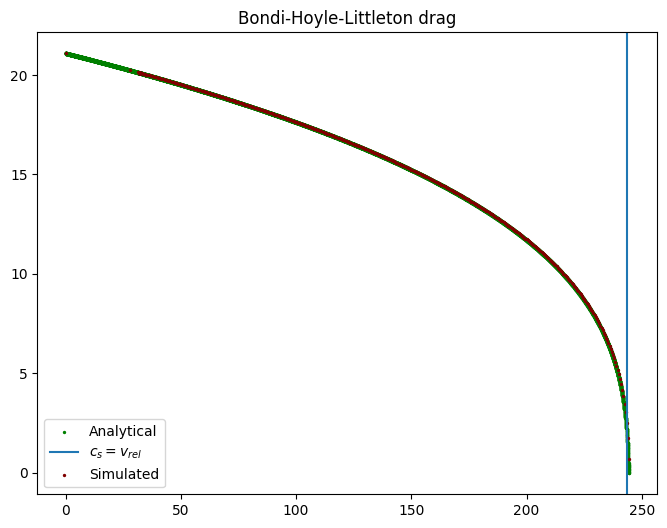

In [15]:
fig, ax = plt.subplots(figsize=(8,6))
# Plot analytical solution
ax.scatter([t.value for t in time], [v.to(u.AU/u.yr).value for v in velocity], s=2, label="Analytical", color="green")
idx_cross = np.where(np.diff(np.sign(np.array(machs) - 1)) != 0)[0]

ax.axvline(x=time[idx_cross[0]].value, label=r"$c_s=v_{rel}$")
# Plot simulated solution
dfi = pd.read_csv("testbhldrag.csv")
df_bhl = dfi[dfi["id"]==0]
t_real = df_bhl["time"] / (2*np.pi)
vdata_real = df_bhl["vx"] * (2*np.pi)
ax.scatter(t_real, vdata_real, color="maroon", s=2, label="Simulated")
ax.set_title("Bondi-Hoyle-Littleton drag")
ax.legend()

In [13]:
v=100*u.km/u.s
cs=10*u.km/u.s
mach = (v/cs).si.value
ts_hl = v**3/(4*np.pi*G**2*M*rho)
ts_bhl = ts_hl * ((1+mach**2)/mach**2)**(1/2)
ts_bhl.to(u.yr)

<Quantity 715.26917095 yr>

In [14]:
rho

<Quantity 1.e-12 kg / cm3>